In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

stock_df = yf.download("GOOGL",start="2025-01-01", end="2026-01-01")

[*********************100%***********************]  1 of 1 completed


In [2]:
stock_df.head()

Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,
2025-01-02,188.445709,191.002363,186.525745,189.659371,20370800
2025-01-03,190.793442,192.206077,188.992849,190.375626,18596200
2025-01-06,195.847046,197.190037,192.842749,192.972063,29563600
2025-01-07,194.474228,199.955592,193.588853,196.085805,26487200
2025-01-08,192.942230,195.270068,191.380396,191.569411,24864800


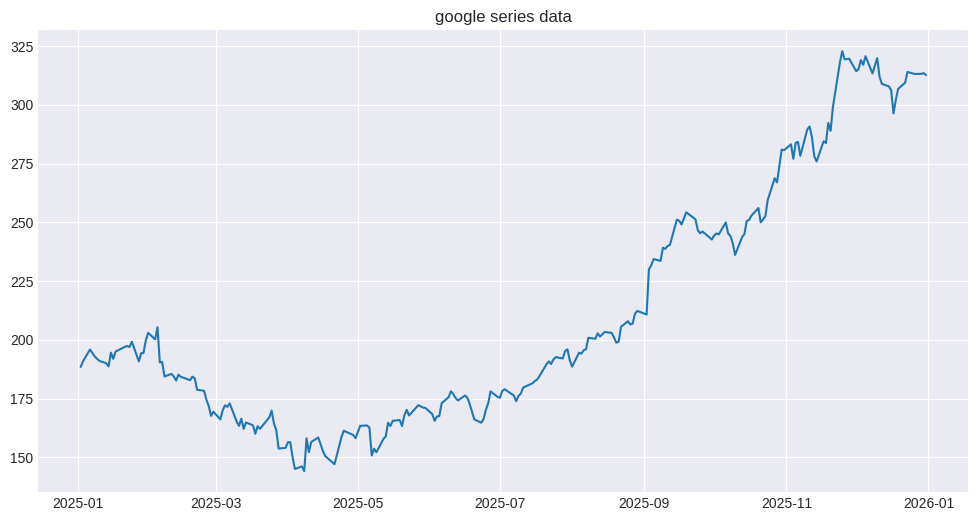

In [3]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(12,6))
plt.plot(stock_df.index,stock_df['Close'],label='Close')
plt.title('google series data')
plt.show()

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

decompostion = seasonal_decompose(stock_df['Close'],model='additive',period=30)

In [5]:
trend = decompostion.trend
seasonal = decompostion.seasonal
residual = decompostion.resid

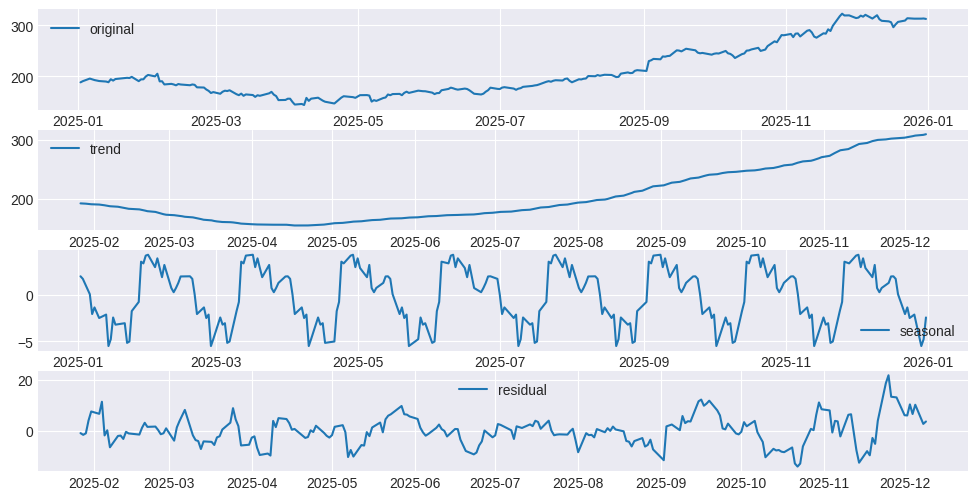

In [6]:
plt.figure(figsize=(12,6))
plt.subplot(411)
plt.plot(stock_df['Close'],label='original')
plt.legend()
plt.subplot(412)
plt.plot(trend,label='trend')
plt.legend()
plt.subplot(413)
plt.plot(seasonal,label='seasonal')
plt.legend()
plt.subplot(414)
plt.plot(residual,label='residual')
plt.legend()
plt.show()

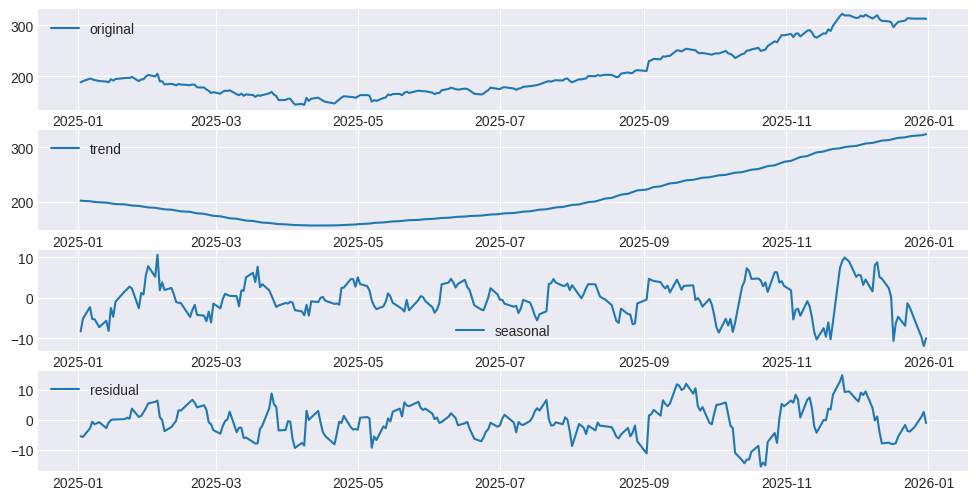

In [7]:
from statsmodels.tsa.seasonal import STL

stl = STL(stock_df['Close'],period=30)
result = stl.fit()

plt.figure(figsize=(12,6))
plt.subplot(411)
plt.plot(result.observed,label='original')
plt.legend()
plt.subplot(412)
plt.plot(result.trend,label='trend')
plt.legend()
plt.subplot(413)
plt.plot(result.seasonal,label='seasonal')
plt.legend()
plt.subplot(414)
plt.plot(result.resid,label='residual')
plt.legend()
plt.show()

In [8]:
from statsmodels.tsa.stattools import adfuller

adf_test = adfuller(stock_df['Close'])

print(f'ADF Statistic: {adf_test[0]}')
print(f'p-value: {adf_test[1]}')
print(f'Critical Values: {adf_test[4]}')

ADF Statistic: 0.8275573156319689
p-value: 0.9920682206603324
Critical Values: {'1%': np.float64(-3.4568881317725864), '5%': np.float64(-2.8732185133016057), '10%': np.float64(-2.5729936189738876)}


In [9]:
from statsmodels.tsa.stattools import kpss

kpss_test = kpss(stock_df['Close'],regression='ct')

print(f'KPSS Statistic: {kpss_test[0]}')
print(f'p-value: {kpss_test[1]}')
print(f'Critical Values: {kpss_test[3]}')

KPSS Statistic: 0.5435677345584772
p-value: 0.01
Critical Values: {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}


/tmp/ipykernel_4089/4101549481.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(stock_df['Close'],regression='ct')


In [10]:
prices = stock_df['Close']

In [11]:
prices

Ticker,GOOGL
Date,
2025-01-02,188.445709
2025-01-03,190.793442
2025-01-06,195.847046
2025-01-07,194.474228
2025-01-08,192.942230
...,...
2025-12-24,313.681702
2025-12-26,313.102448
2025-12-29,313.152374


In [12]:
prices.diff()

Ticker,GOOGL
Date,
2025-01-02,NaN
2025-01-03,2.347733
2025-01-06,5.053604
2025-01-07,-1.372818
2025-01-08,-1.531998
...,...
2025-12-24,-0.259644
2025-12-26,-0.579254
2025-12-29,0.049927
